In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Estilo académico y tipografía clara
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

In [2]:
import sys
print(sys.executable)

c:\Users\jhquiza\repos\ap-2026-1-62\.venv\Scripts\python.exe


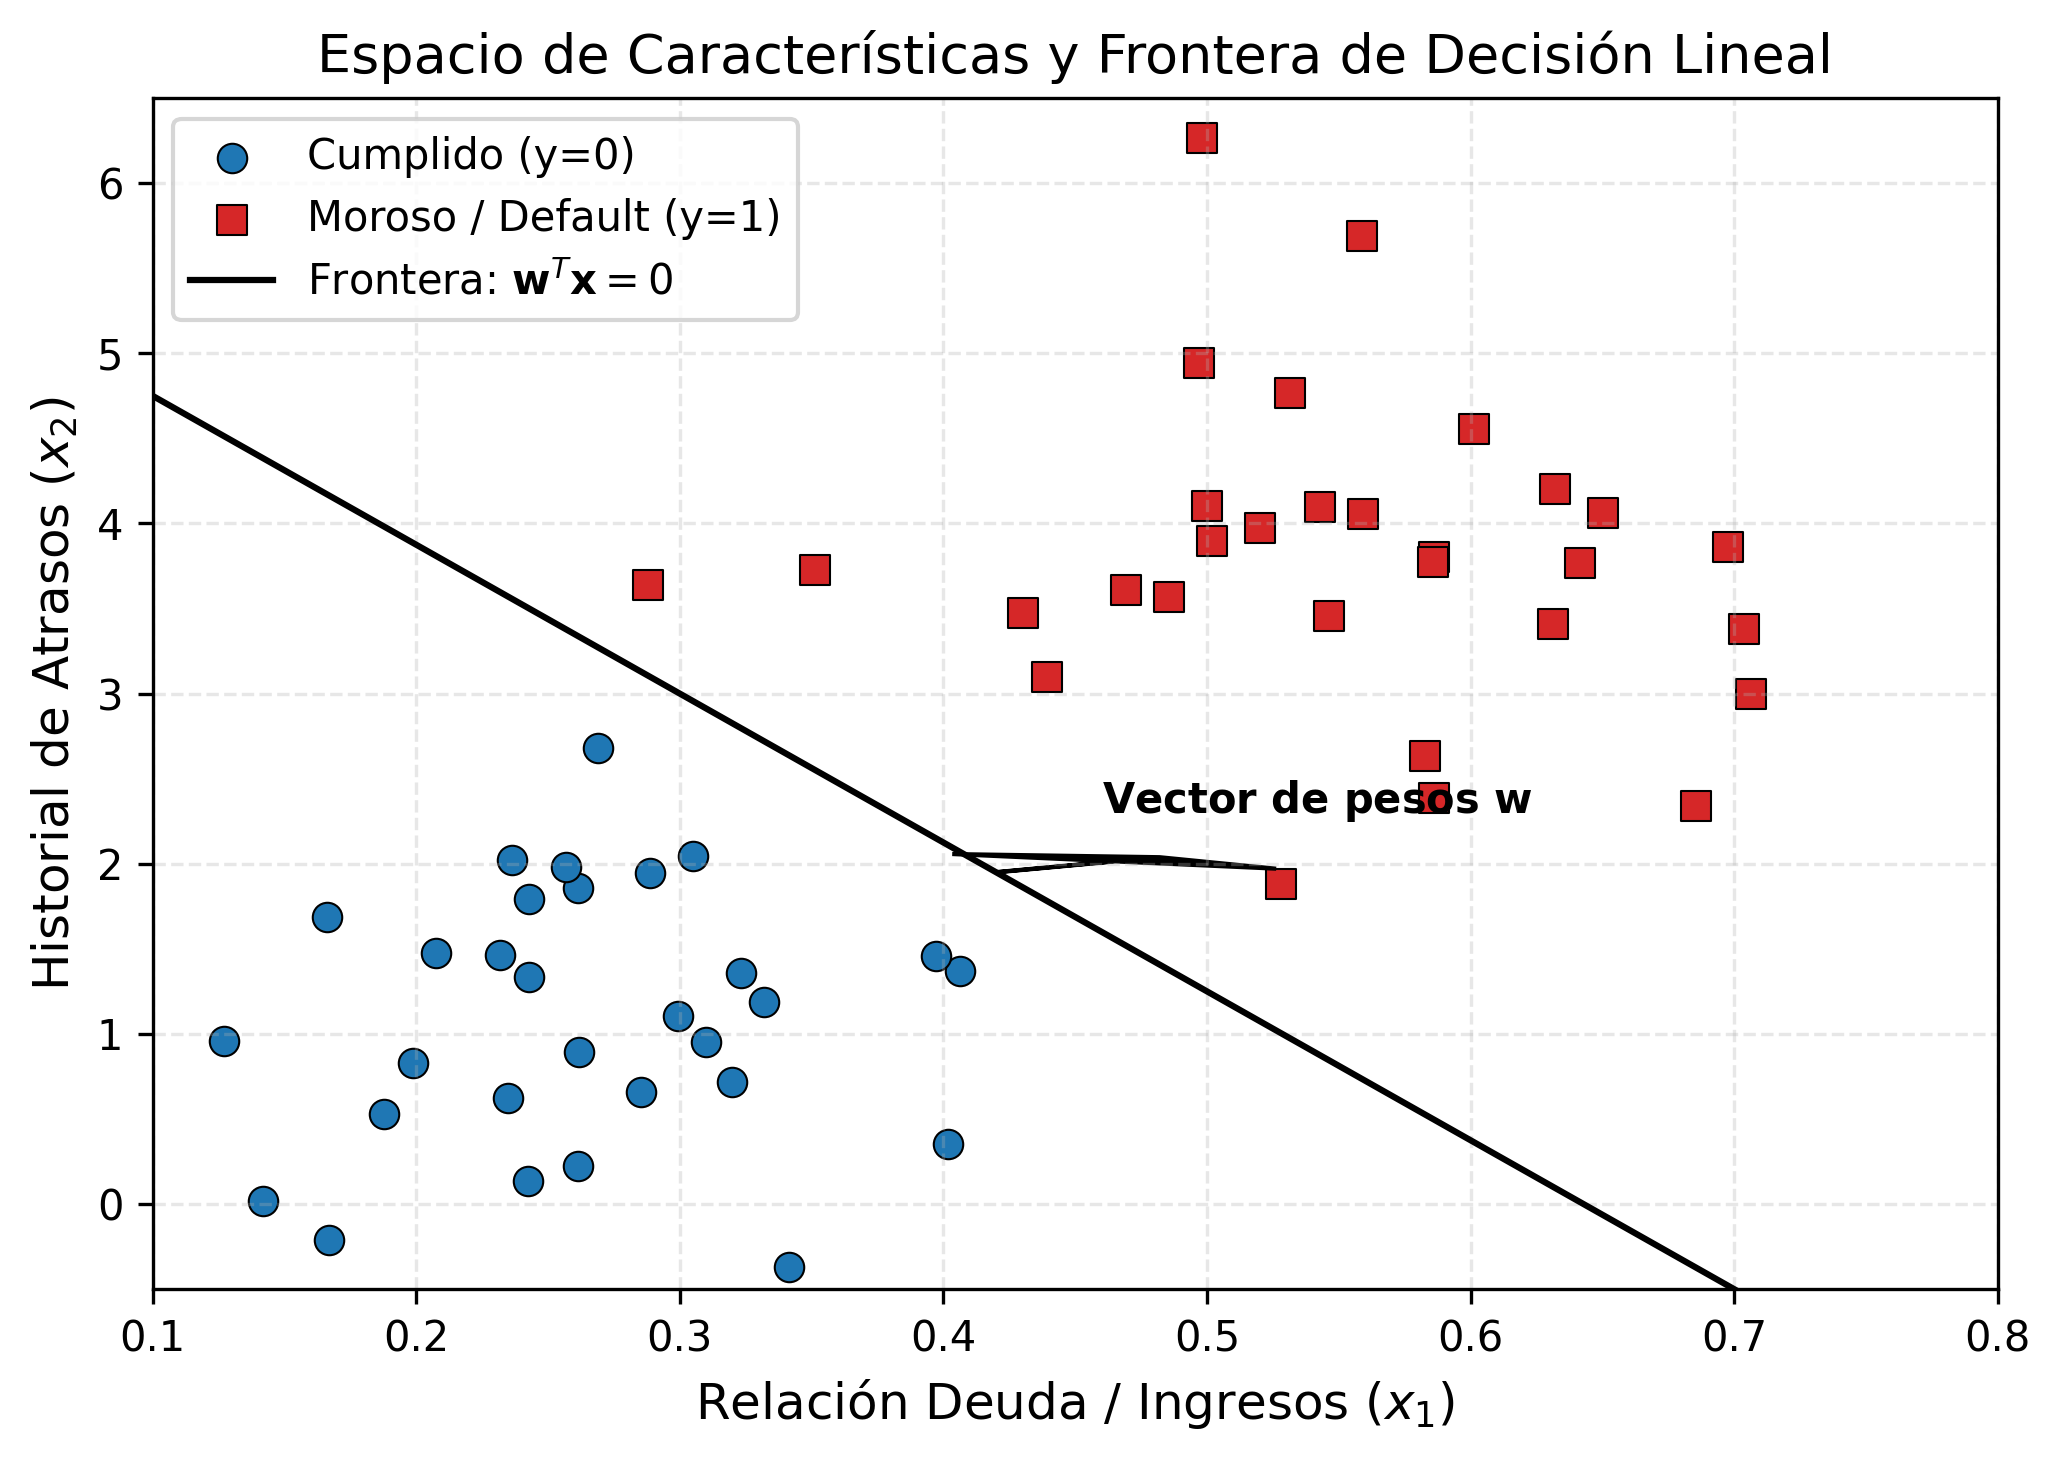

In [6]:
# Semilla para reproducibilidad
np.random.seed(42)

# Datos sintéticos de riesgo de crédito
n_samples = 30
# Clase 0: Solicitantes cumplidos (baja deuda, pocos atrasos)
x1_c0 = np.random.normal(0.28, 0.08, n_samples)
x2_c0 = np.random.normal(1.2, 0.8, n_samples)

# Clase 1: Solicitantes morosos (alta deuda, más atrasos)
x1_c1 = np.random.normal(0.55, 0.10, n_samples)
x2_c1 = np.random.normal(3.8, 1.0, n_samples)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.scatter(x1_c0, x2_c0, color="#1f77b4", marker="o", s=50, edgecolors="k", linewidth=0.5, label="Cumplido (y=0)")
ax.scatter(x1_c1, x2_c1, color="#d62728", marker="s", s=50, edgecolors="k", linewidth=0.5, label="Moroso / Default (y=1)")

# Parámetros hipotéticos de la frontera: w0 + w1*x1 + w2*x2 = 0
w0, w1, w2 = -4.5, 7.0, 0.8
x1_vals = np.linspace(0.1, 0.8, 100)
x2_vals = -(w0 + w1 * x1_vals) / w2

ax.plot(x1_vals, x2_vals, color="black", linestyle="-", linewidth=1.5, label=r"Frontera: $\mathbf{w}^T \mathbf{x} = 0$")

# Vector normal ortogonal w en un punto de la frontera
x_mid = 0.42
y_mid = -(w0 + w1 * x_mid) / w2
scale = 0.08
ax.arrow(x_mid, y_mid, w1 * scale * 0.08, w2 * scale, head_width=0.15, head_length=0.03, fc='black', ec='black')
ax.text(x_mid + 0.04, y_mid + 0.35, r"Vector de pesos $\mathbf{w}$", fontsize=10, weight="bold")

ax.set_xlim(0.1, 0.8)
ax.set_ylim(-0.5, 6.5)
ax.set_xlabel(r"Relación Deuda / Ingresos ($x_1$)")
ax.set_ylabel(r"Historial de Atrasos ($x_2$)")
ax.set_title("Espacio de Características y Frontera de Decisión Lineal")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("p1_d5_frontera_lineal.png")
plt.close()

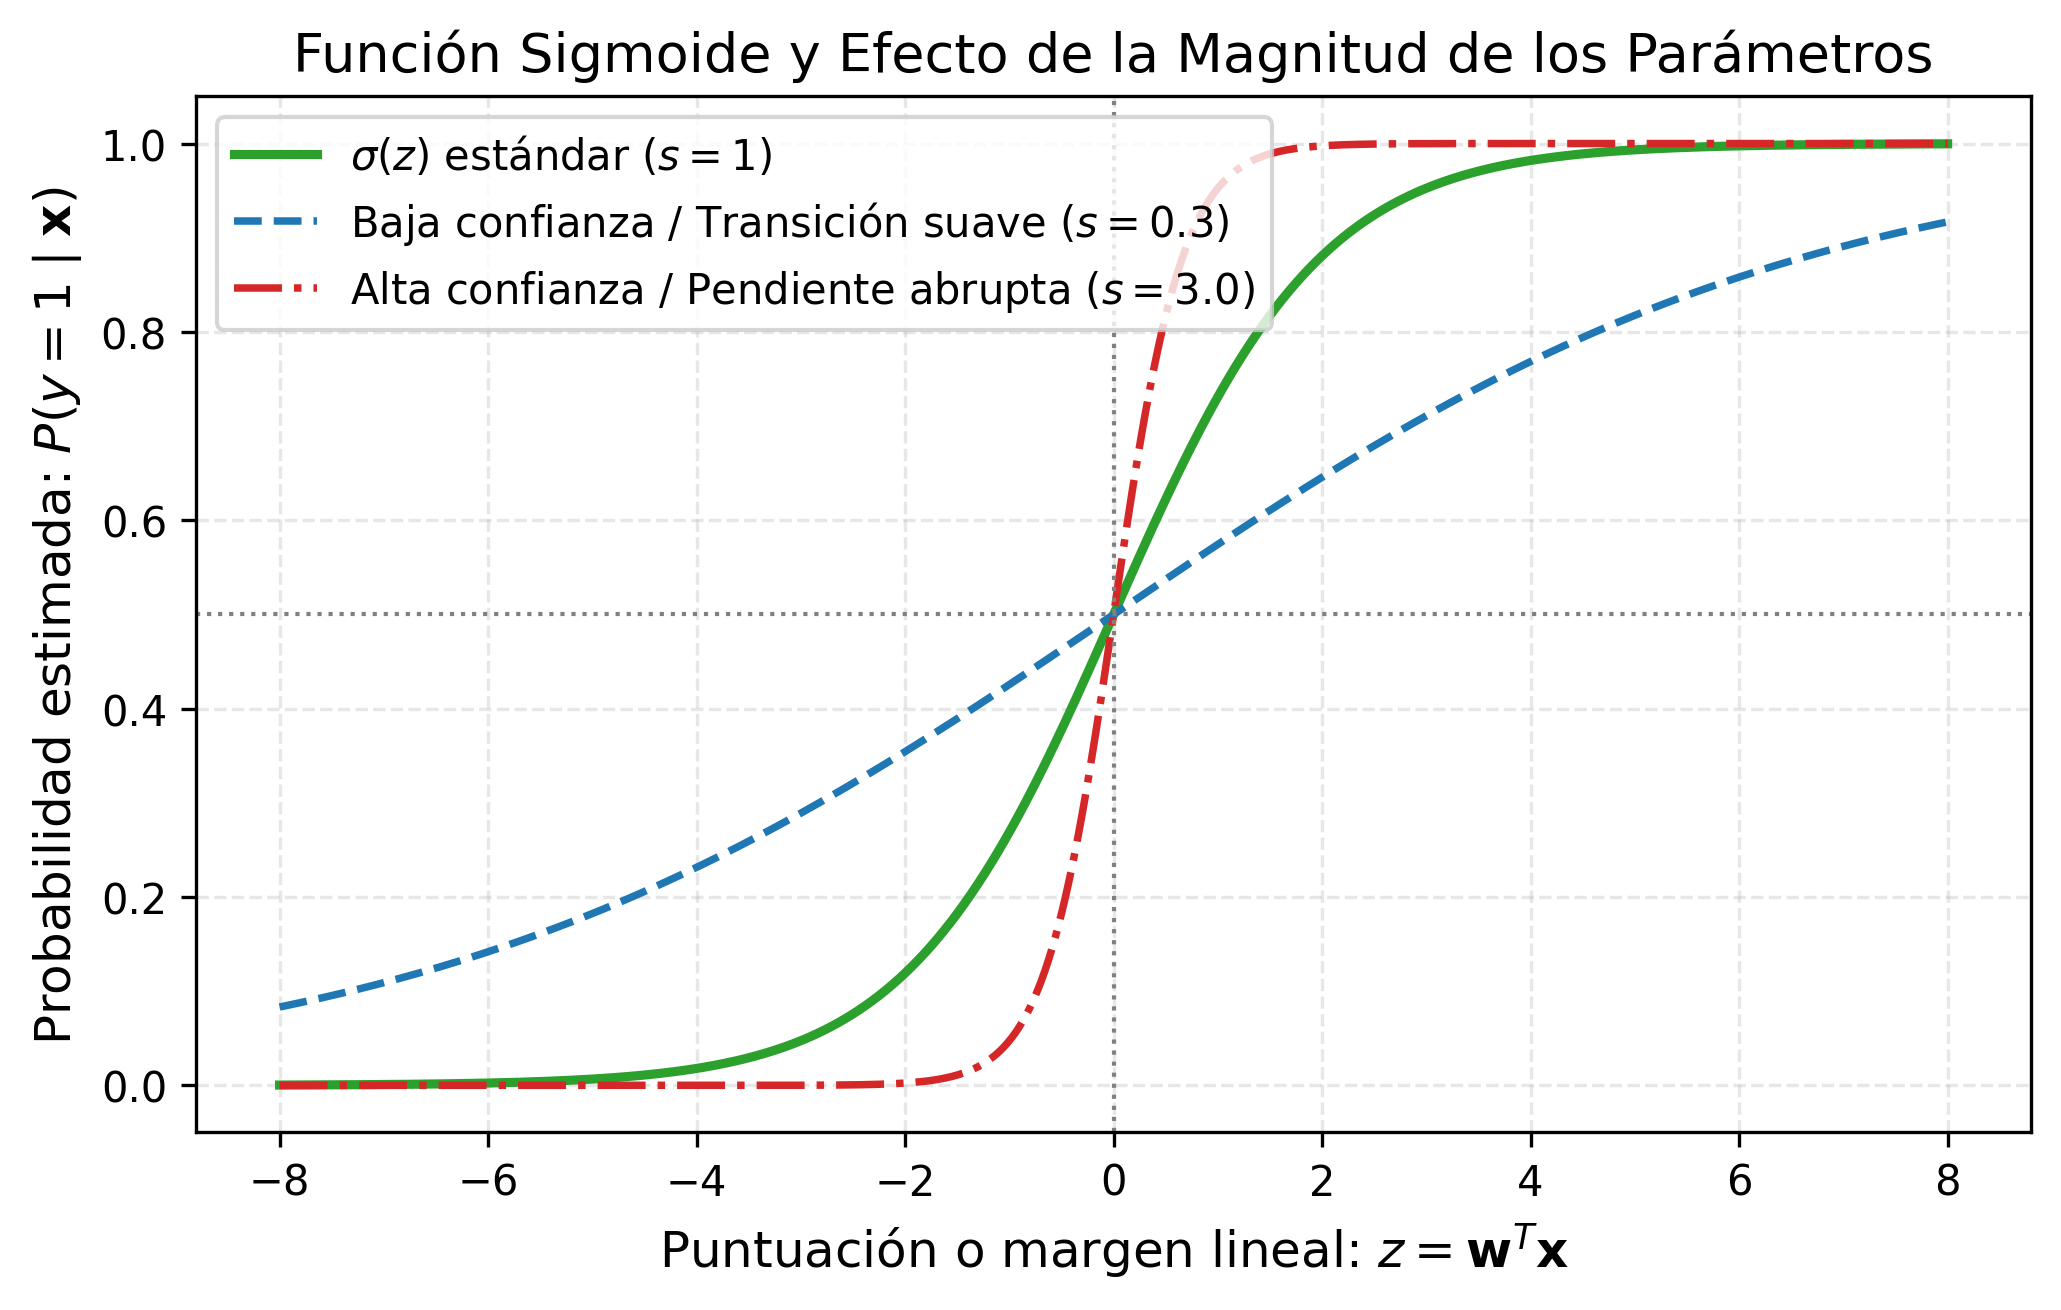

In [5]:
z = np.linspace(-8, 8, 500)
sigma = lambda s: 1.0 / (1.0 + np.exp(-s))

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

ax.plot(z, sigma(z), color="#2ca02c", linewidth=2.2, label=r"$\sigma(z)$ estándar ($s=1$)")
ax.plot(z, sigma(0.3 * z), color="#1f77b4", linestyle="--", linewidth=1.8, label=r"Baja confianza / Transición suave ($s=0.3$)")
ax.plot(z, sigma(3.0 * z), color="#d62728", linestyle="-.", linewidth=1.8, label=r"Alta confianza / Pendiente abrupta ($s=3.0$)")

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.axvline(0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel(r"Puntuación o margen lineal: $z = \mathbf{w}^T \mathbf{x}$")
ax.set_ylabel(r"Probabilidad estimada: $P(y=1 \mid \mathbf{x})$")
ax.set_title("Función Sigmoide y Efecto de la Magnitud de los Parámetros")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("p1_d10_sigmoide_escalas.png")
plt.close()

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\jhquiza\AppData\Local\Temp\ipykernel_9692\3311576306.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Superficie de Probabilidad Estimada $P(y=1 \mid \mathbf{x})$")


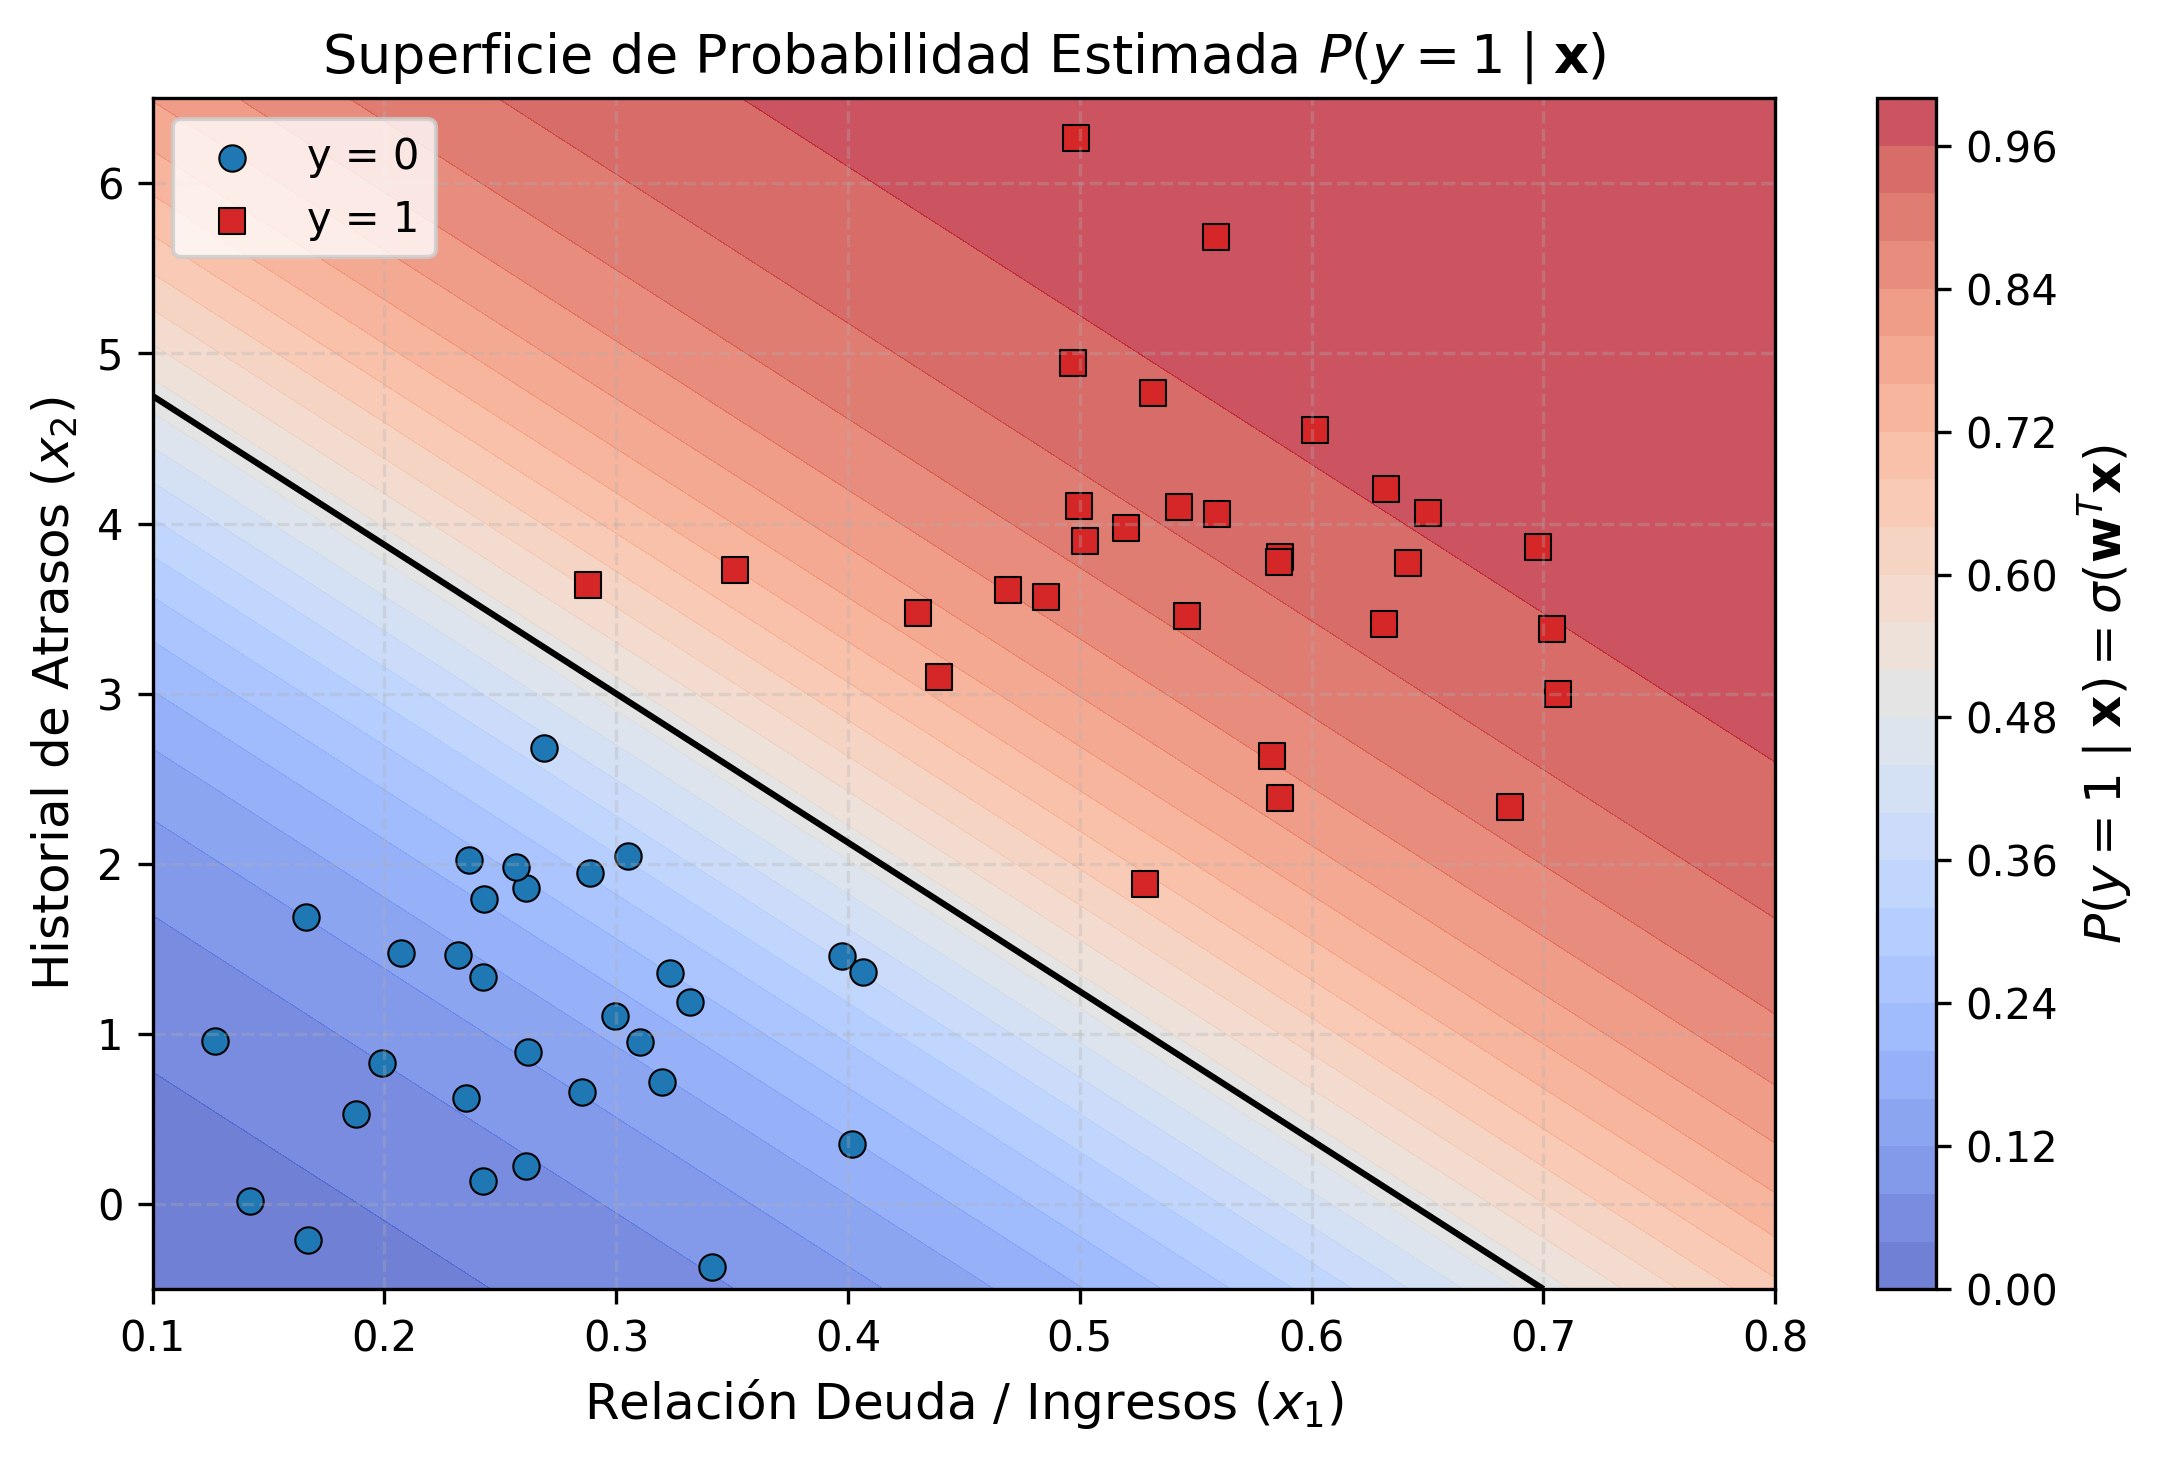

In [7]:
x1_grid, x2_grid = np.meshgrid(np.linspace(0.1, 0.8, 200), np.linspace(-0.5, 6.5, 200))
z_grid = w0 + w1 * x1_grid + w2 * x2_grid
prob_grid = sigma(z_grid)

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=300)

contour = ax.contourf(x1_grid, x2_grid, prob_grid, levels=25, cmap="coolwarm", alpha=0.75)
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label(r"$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x})$")

# Línea de decisión para p = 0.5
ax.contour(x1_grid, x2_grid, prob_grid, levels=[0.5], colors="black", linewidths=1.5, linestyles="-")

ax.scatter(x1_c0, x2_c0, color="#1f77b4", marker="o", s=40, edgecolors="k", linewidth=0.5, label="y = 0")
ax.scatter(x1_c1, x2_c1, color="#d62728", marker="s", s=40, edgecolors="k", linewidth=0.5, label="y = 1")

ax.set_xlabel(r"Relación Deuda / Ingresos ($x_1$)")
ax.set_ylabel(r"Historial de Atrasos ($x_2$)")
ax.set_title("Superficie de Probabilidad Estimada $P(y=1 \mid \mathbf{x})$")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [8]:
plt.savefig("p1_d9_superficie_probabilidad.png")
plt.close()

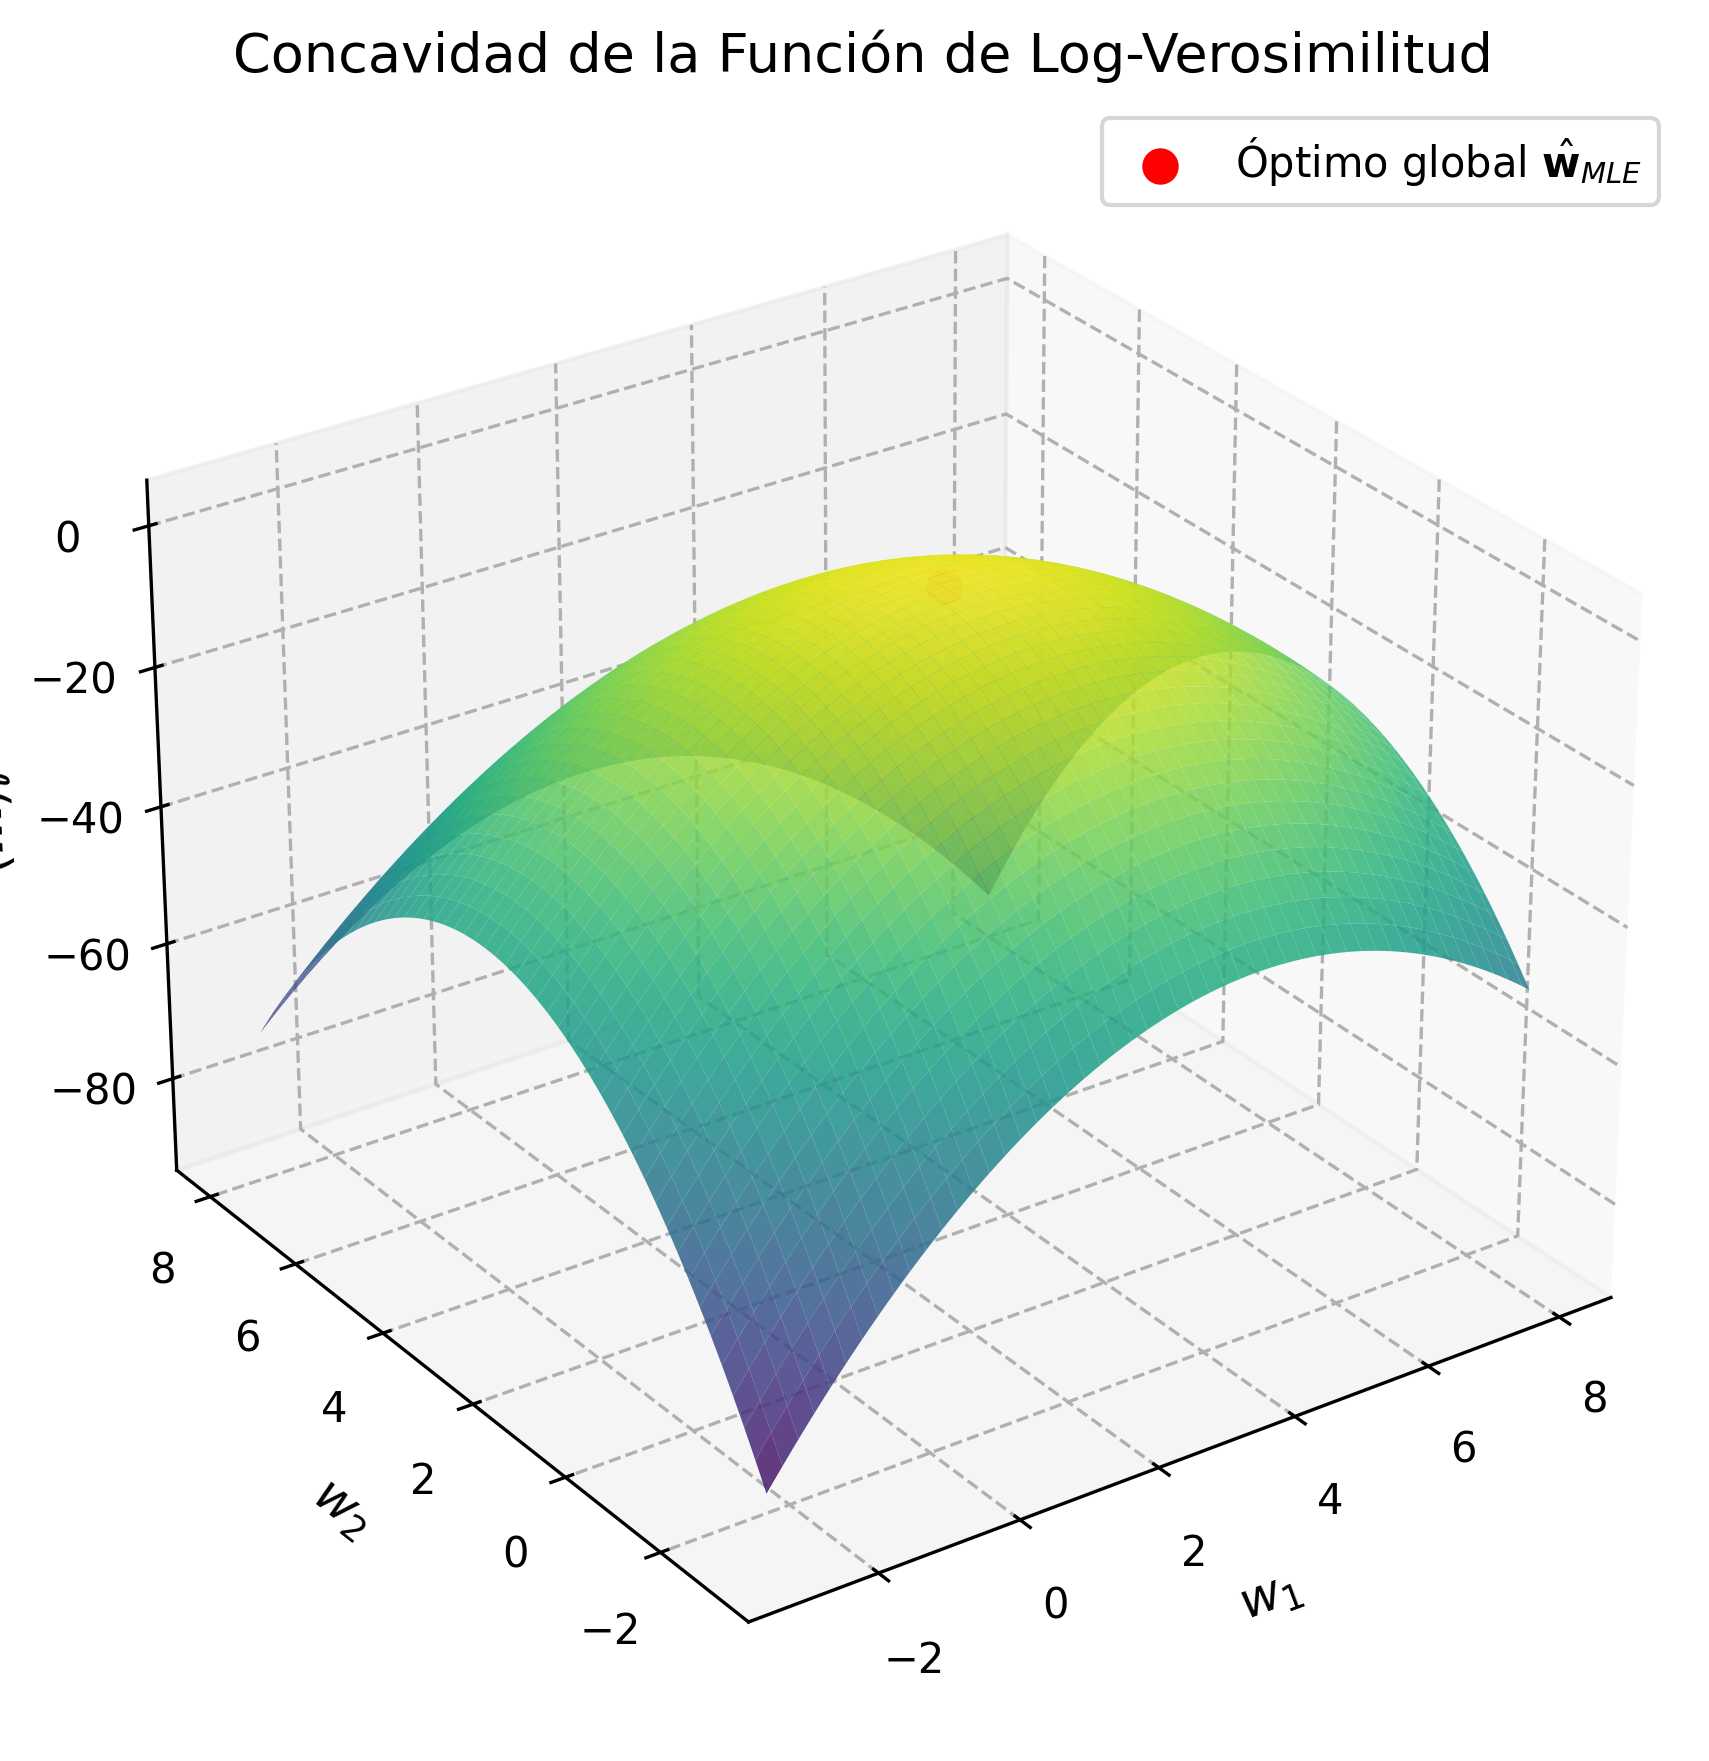

In [9]:
w1_vals = np.linspace(-3, 8, 100)
w2_vals = np.linspace(-3, 8, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

# Aproximación suave y cóncava de la log-verosimilitud alrededor del óptimo w*=(3, 2)
Log_Likelihood = -((W1 - 3.0)**2 + 1.4 * (W2 - 2.0)**2 + 0.4 * (W1 - 3.0) * (W2 - 2.0))

fig = plt.figure(figsize=(8, 6), dpi=300)
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(W1, W2, Log_Likelihood, cmap='viridis', edgecolor='none', alpha=0.85)
ax.scatter([3.0], [2.0], [0.0], color='red', s=60, label=r"Óptimo global $\hat{\mathbf{w}}_{MLE}$")

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_zlabel(r"$\ell(\mathbf{w})$")
ax.set_title("Concavidad de la Función de Log-Verosimilitud")
ax.view_init(elev=28, azim=-125)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
plt.savefig("p2_d5_log_verosimilitud_3d.png")
plt.close()

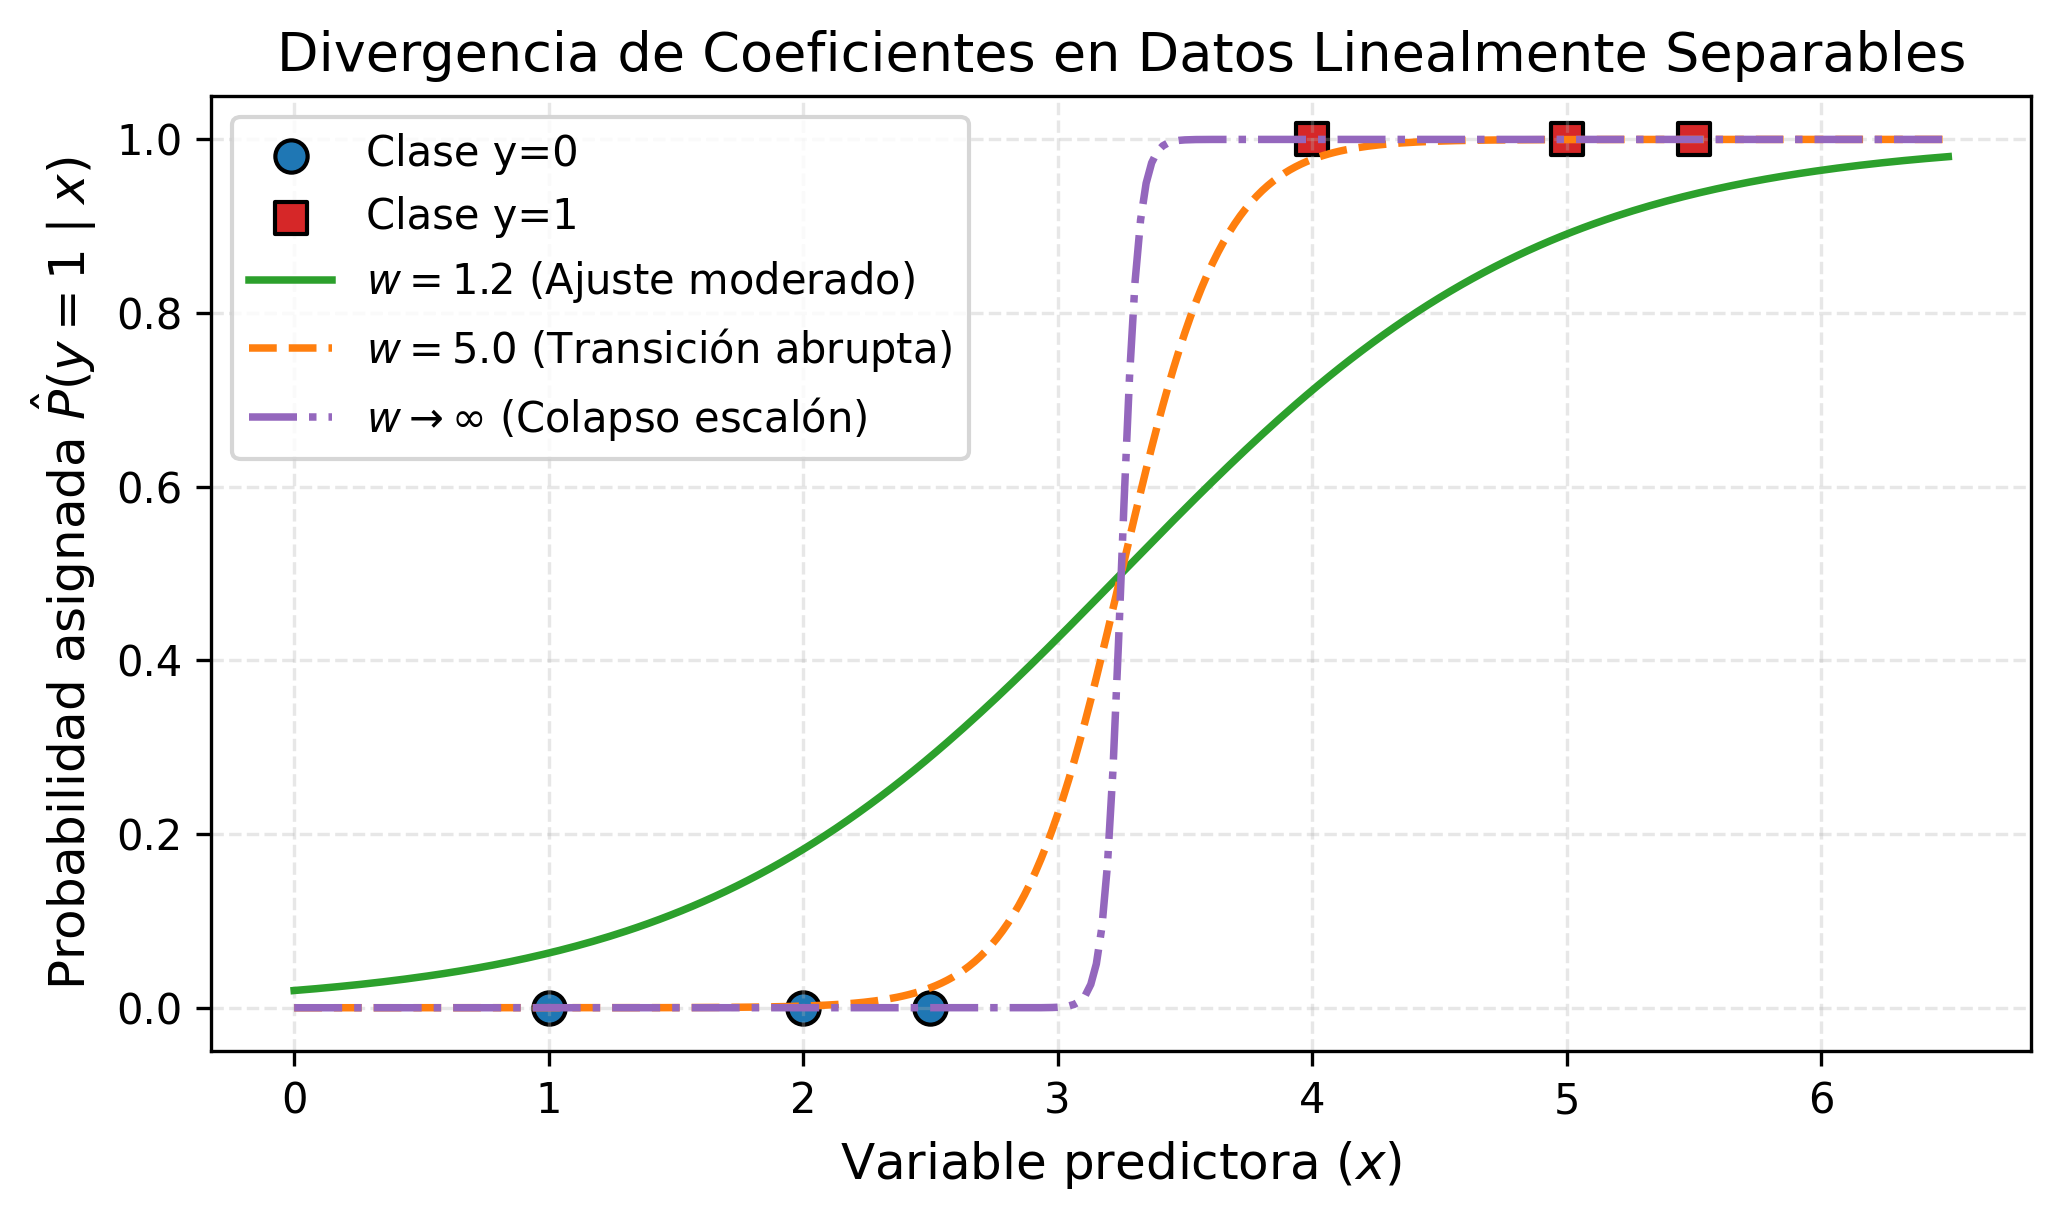

In [11]:
x = np.array([1.0, 2.0, 2.5, 4.0, 5.0, 5.5])
y = np.array([0, 0, 0, 1, 1, 1])

x_dense = np.linspace(0, 6.5, 300)

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=300)

ax.scatter(x[y == 0], y[y == 0], color="#1f77b4", marker="o", s=60, edgecolors="k", label="Clase y=0")
ax.scatter(x[y == 1], y[y == 1], color="#d62728", marker="s", s=60, edgecolors="k", label="Clase y=1")

# Curvas con magnitudes crecientes de pesos (w*(x - 3.25))
for w_val, col, ls, lbl in [
    (1.2, "#2ca02c", "-", r"$w = 1.2$ (Ajuste moderado)"),
    (5.0, "#ff7f0e", "--", r"$w = 5.0$ (Transición abrupta)"),
    (30.0, "#9467bd", "-.", r"$w \to \infty$ (Colapso escalón)")
]:
    ax.plot(x_dense, sigma(w_val * (x_dense - 3.25)), color=col, linestyle=ls, linewidth=1.8, label=lbl)

ax.set_xlabel(r"Variable predictora ($x$)")
ax.set_ylabel(r"Probabilidad asignada $\hat{P}(y=1 \mid x)$")
ax.set_title("Divergencia de Coeficientes en Datos Linealmente Separables")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [12]:
plt.savefig("p2_d7_separabilidad_mle.png")
plt.close()

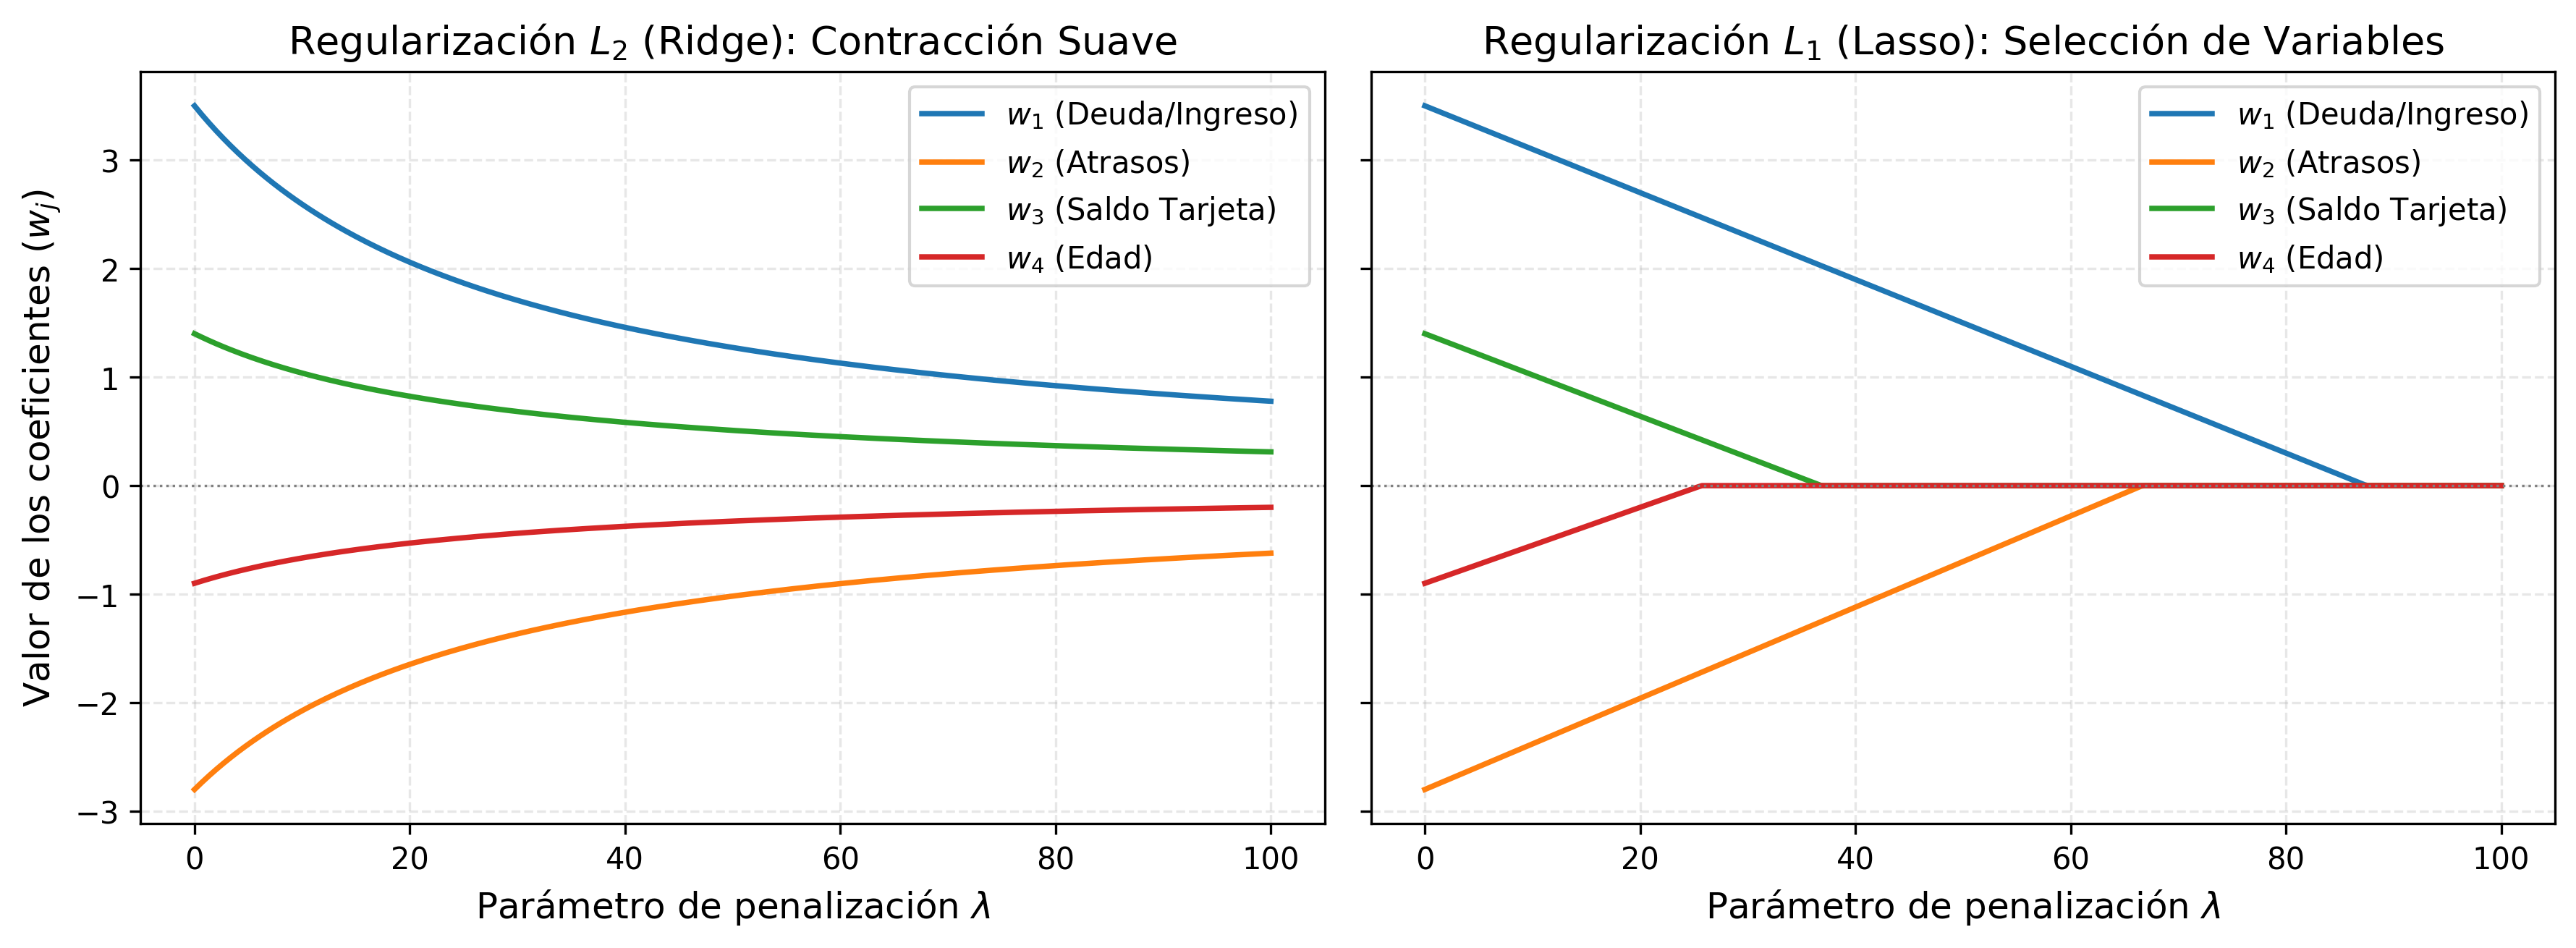

In [13]:
# Simulación analítica de trayectorias de coeficientes
lambdas = np.linspace(0, 100, 300)

# Ridge: contracción cuadrática gradual
w_l2_1 = 3.5 / (1.0 + 0.035 * lambdas)
w_l2_2 = -2.8 / (1.0 + 0.035 * lambdas)
w_l2_3 = 1.4 / (1.0 + 0.035 * lambdas)
w_l2_4 = -0.9 / (1.0 + 0.035 * lambdas)

# Lasso: corte exacto a cero (soft-thresholding)
w_l1_1 = np.sign(3.5) * np.maximum(0, np.abs(3.5) - 0.040 * lambdas)
w_l1_2 = np.sign(-2.8) * np.maximum(0, np.abs(-2.8) - 0.042 * lambdas)
w_l1_3 = np.sign(1.4) * np.maximum(0, np.abs(1.4) - 0.038 * lambdas)
w_l1_4 = np.sign(-0.9) * np.maximum(0, np.abs(-0.9) - 0.035 * lambdas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300, sharey=True)

# Panel L2
ax1.plot(lambdas, w_l2_1, label=r"$w_1$ (Deuda/Ingreso)", linewidth=1.8)
ax1.plot(lambdas, w_l2_2, label=r"$w_2$ (Atrasos)", linewidth=1.8)
ax1.plot(lambdas, w_l2_3, label=r"$w_3$ (Saldo Tarjeta)", linewidth=1.8)
ax1.plot(lambdas, w_l2_4, label=r"$w_4$ (Edad)", linewidth=1.8)
ax1.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax1.set_title(r"Regularización $L_2$ (Ridge): Contracción Suave")
ax1.set_xlabel(r"Parámetro de penalización $\lambda$")
ax1.set_ylabel("Valor de los coeficientes ($w_j$)")
ax1.legend(loc="upper right", frameon=True)

# Panel L1
ax2.plot(lambdas, w_l1_1, label=r"$w_1$ (Deuda/Ingreso)", linewidth=1.8)
ax2.plot(lambdas, w_l1_2, label=r"$w_2$ (Atrasos)", linewidth=1.8)
ax2.plot(lambdas, w_l1_3, label=r"$w_3$ (Saldo Tarjeta)", linewidth=1.8)
ax2.plot(lambdas, w_l1_4, label=r"$w_4$ (Edad)", linewidth=1.8)
ax2.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax2.set_title(r"Regularización $L_1$ (Lasso): Selección de Variables")
ax2.set_xlabel(r"Parámetro de penalización $\lambda$")
ax2.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [14]:
plt.savefig("p2_d10_d11_trayectorias_l1_l2.png")
plt.close()